In [1]:
# R Environment (must be set BEFORE importing rpy2)
import os
os.environ['R_HOME'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R'
os.environ['R_LIBS'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'
os.environ['R_LIBS_USER'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'

# Python Packages
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print(f"\nscanpy: {sc.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print("✓ Python packages loaded")

# rpy2 Setup
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
print(f"\n✓ rpy2 loaded | {ro.r('R.version$version.string')[0]}")

ro.r('suppressPackageStartupMessages(library(lme4))')
lme4_ver = ro.r('as.character(packageVersion("lme4"))')[0]
print(f"✓ R packages: lme4 {lme4_ver}")

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]



scanpy: 1.11.5
numpy: 2.2.6
pandas: 2.3.3
✓ Python packages loaded

✓ rpy2 loaded | R version 4.5.1 (2025-06-13)


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package ‘lme4’ was built under R version 4.5.2 
  


✓ R packages: lme4 1.1.38


In [2]:
import matplotlib.pyplot as plt
try:
    import scanpy as sc
    sc.settings.verbosity = 1
    sc.settings.set_figure_params(dpi=150, dpi_save=300, facecolor='white', frameon=False)
except ImportError:
    pass
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

SEX_COLORS = {'Male': '#5D6D7E', 'Female': '#A569BD',
              'male': '#5D6D7E', 'female': '#A569BD',
              'M': '#5D6D7E', 'F': '#A569BD',
              'm': '#5D6D7E', 'f': '#A569BD',
              '0': '#5D6D7E', '1': '#A569BD', 0: '#5D6D7E', 1: '#A569BD'}

STUDY_GROUP_COLORS = {
    'Age_20_29': '#2E86AB', 'Age_30_39': '#4A90E2', 'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347', 'Age_60_69': '#FF8C00', 'Age_70_79': '#E24A4A',
    'Age_80_100': '#8B0000',
    'Control': '#4E79A7', 'MCI': '#F28E2B', 'AD': '#E15759', 'NCI': '#4E79A7',
    'Young_Healthy_Control': '#4E79A7', 'Old_Healthy_Control': '#59A14F',
    'Old_AD': '#E15759',
    'YHC': '#4E79A7', 'HC': '#59A14F',
}
STUDY_GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
                     'Age_60_69', 'Age_70_79', 'Age_80_100']

COHORT_COLORS = {
    'MSSM': '#2E86AB', 'HBCC': '#E24A4A', 'RUSH': '#50C878',
    'ROSMAP': '#50C878',
    # forest-plot cohorts, dark blue / dark red per edit_3 STYLE
    'PsychAD': '#08306B',
    'PsychENCODE': '#67000D', 'PsychEncode': '#67000D',
    'Mathys': '#67000D',
    # AD-cohort Source levels
    'MSBB': '#2E86AB', 'RADC': '#50C878',
    # S5C Cohort levels, sampled from supplementary page 6
    'CLINCOR': '#4E79A7', 'MAP': '#A0CBE8', 'MARS': '#F28E2B',
    'Mt Sinai Brain Bank': '#FFBE7D', 'ROS': '#59A14F',
}

CELL_TYPE_COLORS = {
    'EN': '#0072B2', 'Excitatory': '#0072B2', 'excitatory': '#0072B2',
    'IN': '#E69F00', 'Inhibitory': '#E69F00', 'inhibitory': '#E69F00',
    'Astro': '#009E73', 'Astrocyte': '#009E73', 'Astrocytes': '#009E73',
    'Oligo': '#56B4E9', 'Oligodendrocyte': '#56B4E9', 'Oligodendrocytes': '#56B4E9',
    'OPC': '#CC79A7', 'OPCs': '#CC79A7',
    'Micro': '#D55E00', 'Microglia': '#D55E00',
    'Endo': '#7F7F7F', 'Endothelial': '#7F7F7F',
    'Vascular': '#7F7F7F', 'vascular': '#7F7F7F',
    'PVM': '#D37295', 'Pericyte': '#999999', 'Mural': '#999999',
    'VSMC': '#9C755F', 'VLMC': '#BAB0AC', 'OVM': '#9C755F',
    'Adaptive': '#FABFD2', 'Immune': '#B6992D', 'immune': '#B6992D',
    # astrocyte states, Fig 3A-3D
    'Homeostatic': '#4E79A7', 'Intermediate': '#59A14F', 'Reactive': '#E15759',
    'Trophic': '#F28E2B', 'Metabolic': '#EDC948',
    # OPC states, Fig 3E-3H. Homeostatic and Reactive shared with astrocytes
    'COP': '#59A14F',
}

# microglia Homeostatic is grey, not blue, so these cannot live in CELL_TYPE_COLORS
MICROGLIA_STATE_COLORS = {
    'Homeostatic': '#B0B7BC', 'ARM': '#F5A623', 'IRM': '#2E86C1',
    'Stress': '#8E44AD', 'DAM_like': '#E4002B',
}

PALETTES = {'sex': SEX_COLORS,
            'study_group': STUDY_GROUP_COLORS,
            'cohort': COHORT_COLORS,
            'cell_type': CELL_TYPE_COLORS,
            'microglia_state': MICROGLIA_STATE_COLORS}

def color_for(variable, levels, missing='#808080'):
    if variable not in PALETTES:
        raise KeyError(f"no PALETTES['{variable}']. have: {sorted(PALETTES)}")
    pal = PALETTES[variable]
    out = [pal.get(str(lv), missing) for lv in levels]
    gaps = [str(lv) for lv, c in zip(levels, out) if c == missing]
    if gaps:
        print(f"WARNING: no {variable} color for {sorted(set(gaps))}, using grey")
    return out

print(f"✓ palettes configured: {', '.join(sorted(PALETTES))}")

✓ palettes configured: cell_type, cohort, microglia_state, sex, study_group


# Figure 3A

colours: {'Homeostatic': '#4E79A7', 'Intermediate': '#59A14F', 'Reactive': '#E15759', 'Trophic': '#F28E2B', 'Metabolic': '#EDC948'}
51,631 cells
group
Age_20_29      8770
Age_30_39      4754
Age_40_49     10367
Age_50_59      5742
Age_60_69      5629
Age_70_79      8853
Age_80_100     7516


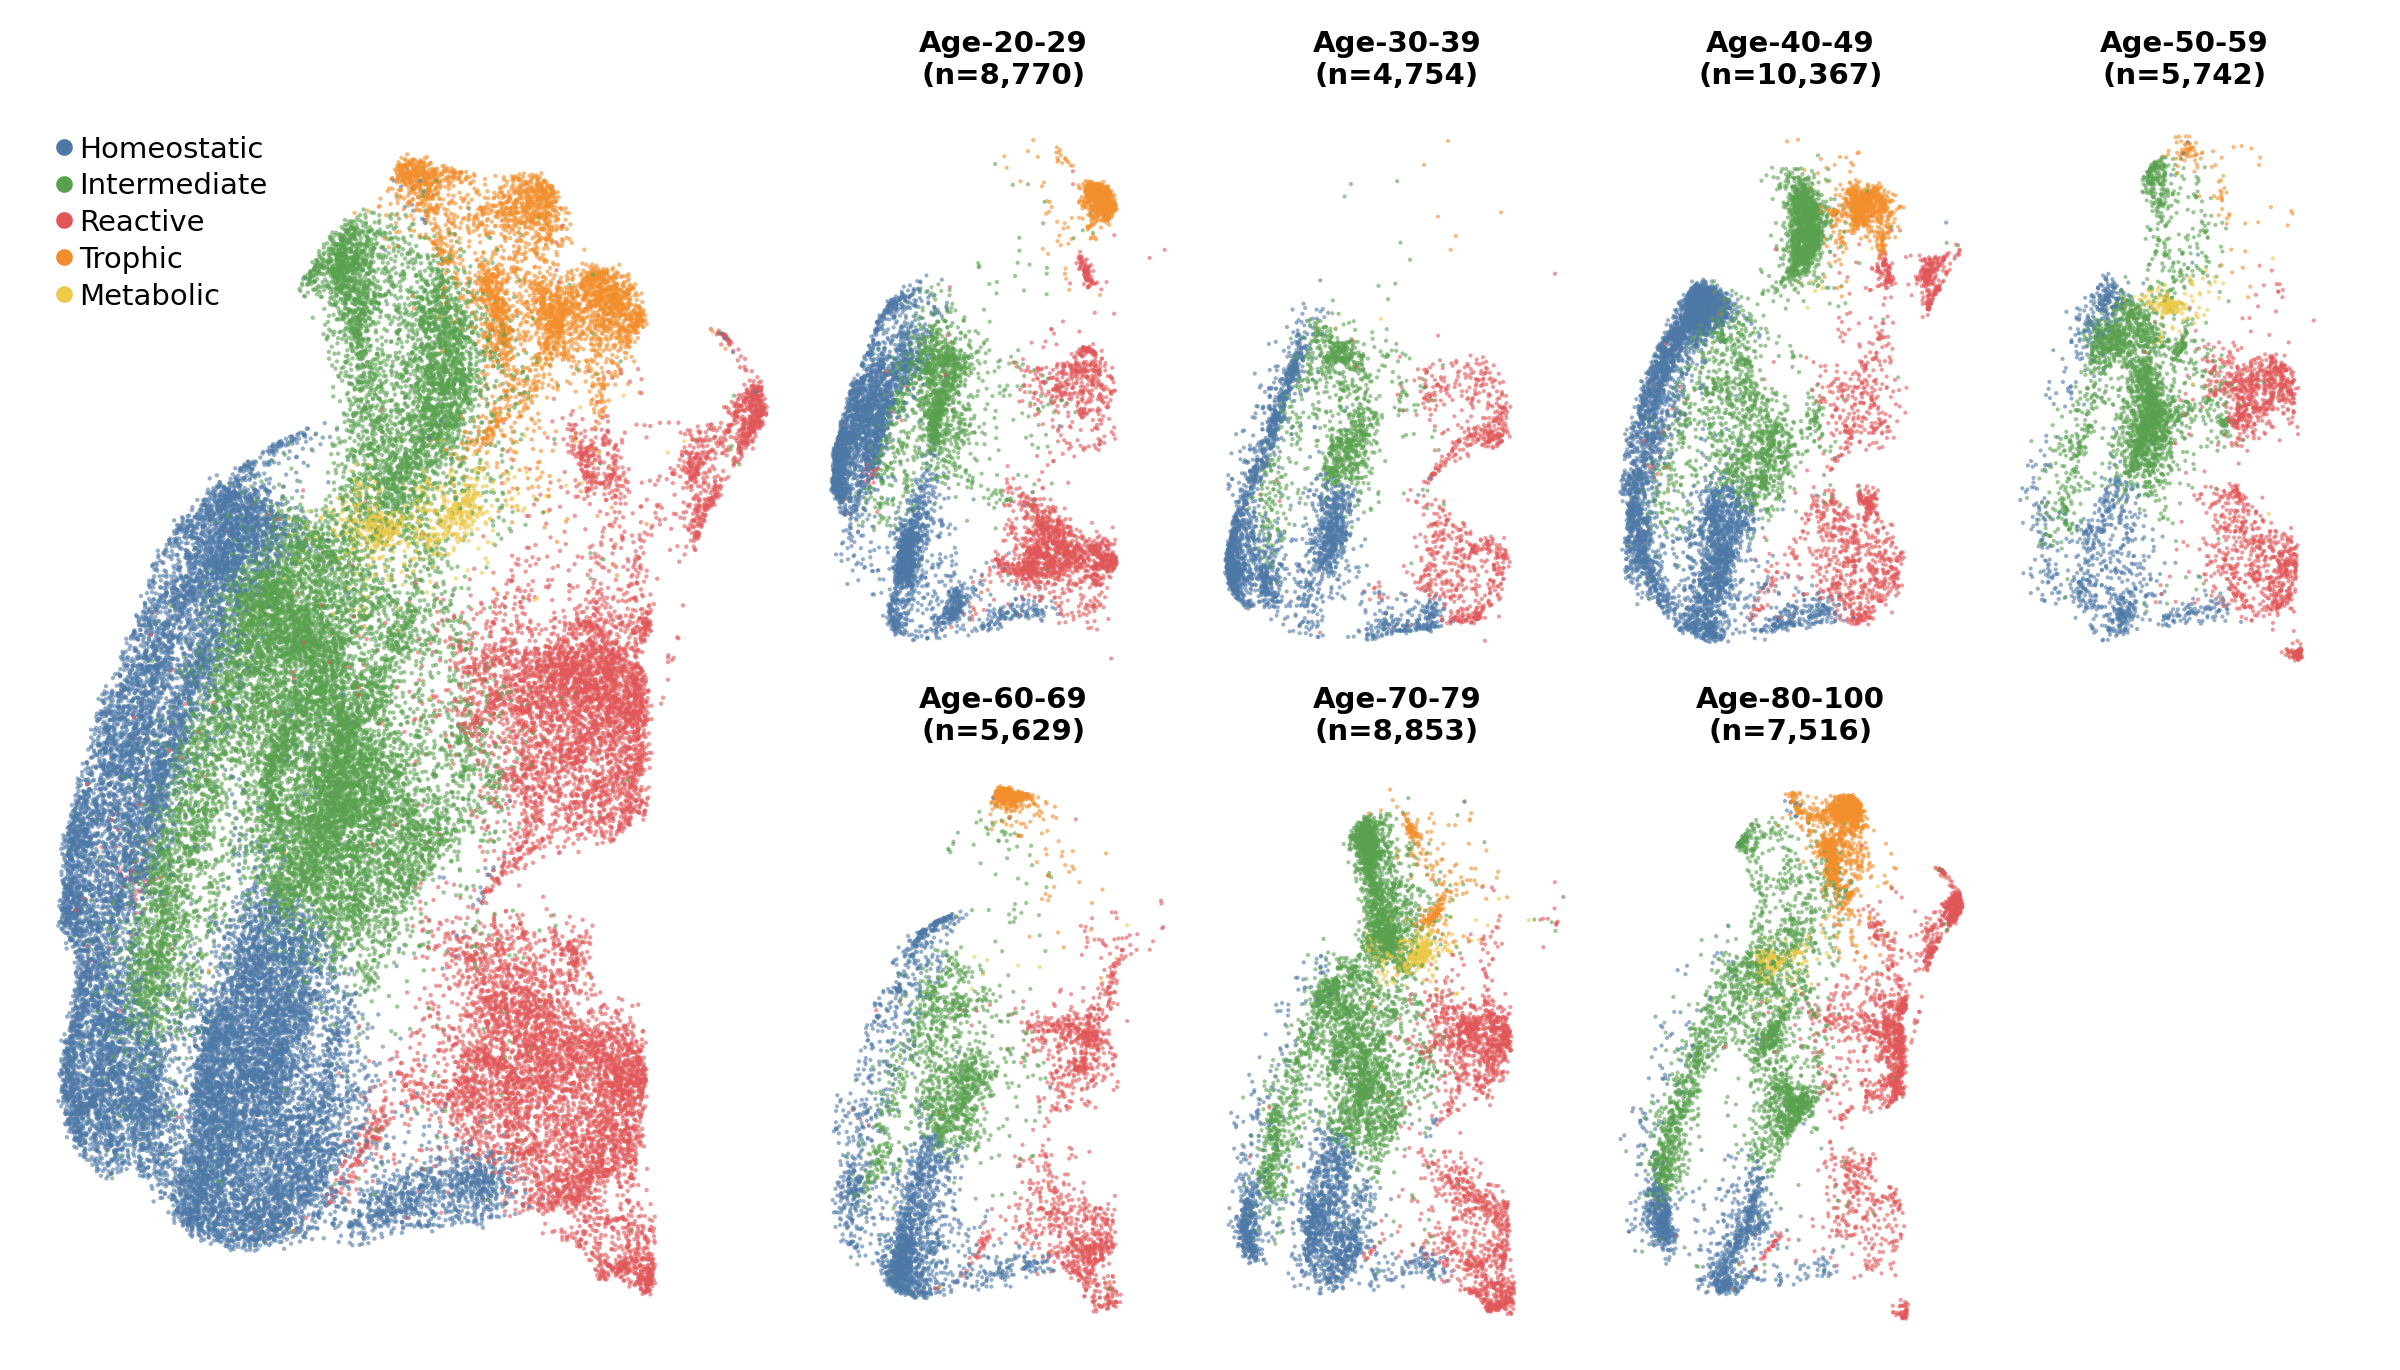

In [3]:
SRC     = 'results/fig3A&B_source_data.csv'
COLOURS = 'results/fig3A&B_colours.csv'
STATE_ORDER = ['Homeostatic', 'Intermediate', 'Reactive', 'Trophic', 'Metabolic']
GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
               'Age_60_69', 'Age_70_79', 'Age_80_100']
NCOL_SMALL  = 4
SEED        = 0
S_BIG, S_SMALL = 1.1, 1.0
ALPHA       = 0.6
RASTERIZE   = True
PAD         = 0.04

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

d = pd.read_csv(SRC)
pal = pd.read_csv(COLOURS)
cmap = dict(zip(pal.state, pal.colour))
miss = [s for s in STATE_ORDER if s not in cmap]
if miss:
    raise KeyError(f"no colour for {miss}. file has {sorted(cmap)}")
bad = sorted(set(d.state) - set(STATE_ORDER)) + sorted(set(d.group) - set(GROUP_ORDER))
if bad:
    raise ValueError(f"levels not in ORDER: {bad}")
print("colours:", {s: cmap[s] for s in STATE_ORDER})
print(f"{len(d):,} cells")
print(d.groupby('group', observed=True).size().reindex(GROUP_ORDER).to_string())

xr = d.UMAP1.max() - d.UMAP1.min(); yr = d.UMAP2.max() - d.UMAP2.min()
XL = (d.UMAP1.min() - PAD*xr, d.UMAP1.max() + PAD*xr)
YL = (d.UMAP2.min() - PAD*yr, d.UMAP2.max() + PAD*yr)
rng = np.random.default_rng(SEED)

def draw(ax, sub, s):
    sub = sub.iloc[rng.permutation(len(sub))]
    ax.scatter(sub.UMAP1, sub.UMAP2, s=s, c=sub.state.map(cmap).values,
               alpha=ALPHA, linewidths=0, rasterized=RASTERIZE)
    ax.set_xlim(*XL); ax.set_ylim(*YL)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig = plt.figure(figsize=(3.0 + 1.75*NCOL_SMALL, 5.4))
gs  = GridSpec(2, 2 + NCOL_SMALL, figure=fig, wspace=0.06, hspace=0.14)

axb = fig.add_subplot(gs[0:2, 0:2])
draw(axb, d, S_BIG)
axb.legend(handles=[Line2D([], [], marker='o', color='w', markerfacecolor=cmap[s],
                           markersize=5, label=s) for s in STATE_ORDER],
           loc='upper left', frameon=False, fontsize=7,
           handletextpad=0.3, labelspacing=0.3)

for i, g in enumerate(GROUP_ORDER):
    ax = fig.add_subplot(gs[i // NCOL_SMALL, 2 + i % NCOL_SMALL])
    sub = d[d.group == g]
    draw(ax, sub, S_SMALL)
    ax.set_title(f"{g.replace('Age_', 'Age-').replace('_', '-')}\n(n={len(sub):,})",
                 fontsize=7, fontweight='bold')
for i in range(len(GROUP_ORDER), 2 * NCOL_SMALL):
    fig.add_subplot(gs[i // NCOL_SMALL, 2 + i % NCOL_SMALL]).set_visible(False)

plt.show()

# Figure 3B

cells per group: {'Age_20_29': 8770, 'Age_30_39': 4754, 'Age_40_49': 10367, 'Age_50_59': 5742, 'Age_60_69': 5629, 'Age_70_79': 8853, 'Age_80_100': 7516}

proportion (%)
state       Homeostatic  Intermediate  Reactive  Trophic  Metabolic
group                                                              
Age_20_29         48.59         19.60     23.53     8.27       0.01
Age_30_39         57.61         23.85     18.36     0.13       0.04
Age_40_49         49.34         28.41     14.19     7.98       0.09
Age_50_59         17.89         51.17     26.04     1.67       3.24
Age_60_69         42.78         25.12     24.11     7.85       0.14
Age_70_79         21.61         50.27     20.92     3.04       4.17
Age_80_100        17.20         37.03     25.49    17.80       2.47


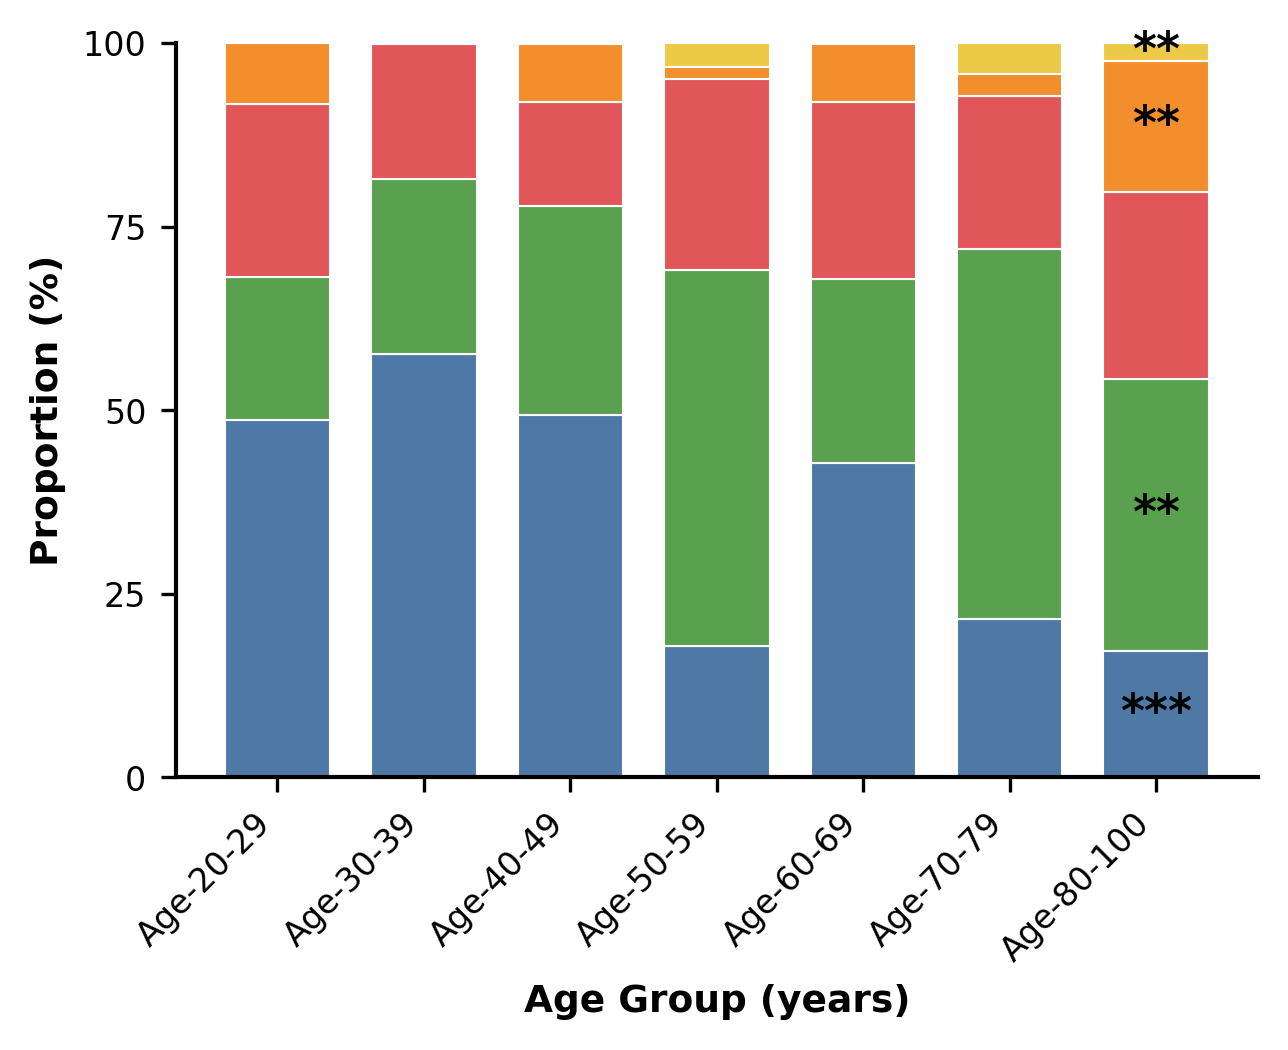

In [4]:
SRC     = 'results/fig3A&B_source_data.csv'
COLOURS = 'results/fig3A&B_colours.csv'
STACK_ORDER = ['Homeostatic', 'Intermediate', 'Reactive', 'Trophic', 'Metabolic']
GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
               'Age_60_69', 'Age_70_79', 'Age_80_100']
# significance from the per-decade trend test. {state: {group: symbol}}
ANNOT = {'Metabolic':     {'Age_80_100': '**'},
         'Homeostatic': {'Age_80_100': '***'},
         'Trophic': {'Age_80_100': '**'},
         'Intermediate': {'Age_80_100': '**'}}
BAR_W = 0.72

import numpy as np, pandas as pd, matplotlib.pyplot as plt

d = pd.read_csv(SRC)
cmap = dict(pd.read_csv(COLOURS)[['state', 'colour']].values)
miss = [s for s in STACK_ORDER if s not in cmap]
if miss:
    raise KeyError(f"no colour for {miss}")

n = pd.crosstab(d.group, d.state).reindex(index=GROUP_ORDER, columns=STACK_ORDER)
n = n.fillna(0)
pct = n.div(n.sum(axis=1), axis=0) * 100
print("cells per group:", n.sum(axis=1).astype(int).to_dict())
print("\nproportion (%)")
print(pct.round(2).to_string())

x, bottom = np.arange(len(GROUP_ORDER)), np.zeros(len(GROUP_ORDER))
fig, ax = plt.subplots(figsize=(4.4, 3.6))
for st in STACK_ORDER:
    v = pct[st].values
    ax.bar(x, v, bottom=bottom, width=BAR_W, color=cmap[st],
           edgecolor='white', linewidth=0.5, label=st, zorder=2)
    for g, sym in ANNOT.get(st, {}).items():
        if g in GROUP_ORDER:
            i = GROUP_ORDER.index(g)
            ax.text(x[i], bottom[i] + v[i] / 2, sym, ha='center', va='center',
                    fontsize=11, fontweight='bold', zorder=5)
    bottom = bottom + v

ax.set_xticks(x)
ax.set_xticklabels([g.replace('Age_', 'Age-').replace('_', '-') for g in GROUP_ORDER],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion (%)', fontsize=9, fontweight='bold')
ax.set_xlabel('Age Group (years)', fontsize=9, fontweight='bold')
ax.set_ylim(0, 100); ax.set_yticks([0, 25, 50, 75, 100])
ax.tick_params(labelsize=8)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

# Figure 3C

Fig3C colours: {'Trophic': '#F28E2B', 'Homeostatic': '#4E79A7', 'Reactive': '#E15759', 'Intermediate': '#59A14F', 'Metabolic': '#EDC948'}
270 rows, 5 states, min cells 20
  Trophic        median= 27.0  mean= 31.1  n=11
  Homeostatic    median=  6.2  mean=  8.3  n=84
  Reactive       median=  5.8  mean=  8.4  n=104
  Intermediate   median=  3.4  mean=  5.0  n=64
  Metabolic      median=  2.1  mean=  3.4  n=7


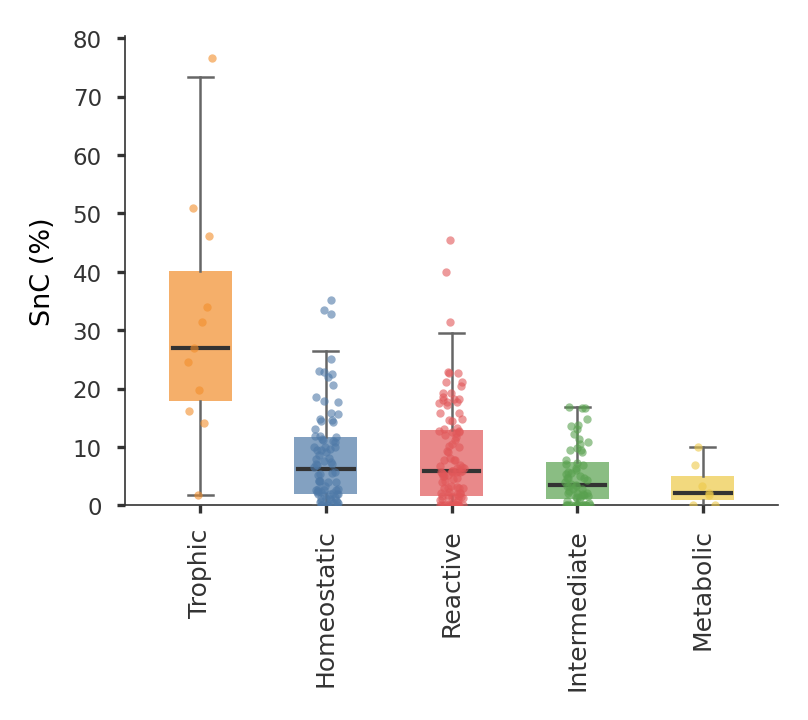

In [5]:
SRC = 'results/fig3C_source_data.csv'

ORDER_BY_MEDIAN = True          # False keeps the file's order
STATE_ORDER = None              # or an explicit list
JITTER_SEED = 42                # seed i uses JITTER_SEED + i, matching the R original
JITTER_W    = 0.10
BOX_HW      = 0.25
BOX_ALPHA   = 0.7
DOT_ALPHA   = 0.6
DOT_S       = 4

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

if 'color_for' not in globals():
    raise NameError("run the settings cell first, the one that defines "
                    "PALETTES and color_for")

d = pd.read_csv(SRC)

if STATE_ORDER is not None:
    order = list(STATE_ORDER)
elif ORDER_BY_MEDIAN:
    order = (d.groupby('state').pct_snc.median()
               .sort_values(ascending=False).index.tolist())
else:
    order = list(dict.fromkeys(d.state))
cmap = dict(zip(order, color_for('cell_type', order)))
print("Fig3C colours:", cmap)

print(f"{len(d)} rows, {len(order)} states, min cells {int(d.n_cells.min())}")
for s in order:
    v = d.loc[d.state == s, 'pct_snc']
    print(f"  {s:<14} median={v.median():5.1f}  mean={v.mean():5.1f}  n={len(v)}")

ymax = d.pct_snc.max() * 1.05
fig, ax = plt.subplots(figsize=(2.8, 2.5))

for i, s in enumerate(order, start=1):
    v = d.loc[d.state == s, 'pct_snc'].values
    c = cmap[s]
    q0, q1, q2, q3, q4 = np.quantile(v, [0, .25, .5, .75, 1])
    iqr = q3 - q1
    lo, hi = max(q0, q1 - 1.5 * iqr), min(q4, q3 + 1.5 * iqr)

    ax.add_patch(Rectangle((i - BOX_HW, q1), 2 * BOX_HW, q3 - q1,
                           facecolor=c, alpha=BOX_ALPHA, edgecolor='none', zorder=2))
    ax.plot([i - 0.22, i + 0.22], [q2, q2], color='#333333', lw=1.0, zorder=4)
    ax.plot([i, i], [lo, q1], color='#666666', lw=0.6, zorder=3)
    ax.plot([i, i], [q3, hi], color='#666666', lw=0.6, zorder=3)
    for y in (lo, hi):
        ax.plot([i - 0.1, i + 0.1], [y, y], color='#666666', lw=0.6, zorder=3)

    rng = np.random.default_rng(JITTER_SEED + i)
    ax.scatter(i + rng.uniform(-JITTER_W, JITTER_W, len(v)), v,
               s=DOT_S, color=c, alpha=DOT_ALPHA, linewidths=0, zorder=5)

ax.set_xlim(0.4, len(order) + 0.6)
ax.set_ylim(0, ymax)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=90, fontsize=6, color='#333333')
ax.set_ylabel('SnC (%)', fontsize=6.5)
ax.tick_params(axis='y', labelsize=5.5, colors='#333333', length=2)
ax.tick_params(axis='x', length=2, colors='#333333')
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_color('#333333'); ax.spines[sp].set_linewidth(0.4)
fig.tight_layout()
plt.show()

# Figure 3D

Fig3D colours: {'Trophic': '#F28E2B', 'Reactive': '#E15759', 'Metabolic': '#EDC948', 'Intermediate': '#59A14F', 'Homeostatic': '#4E79A7'}
stack order, left to right: ['Trophic', 'Reactive', 'Metabolic', 'Intermediate', 'Homeostatic']


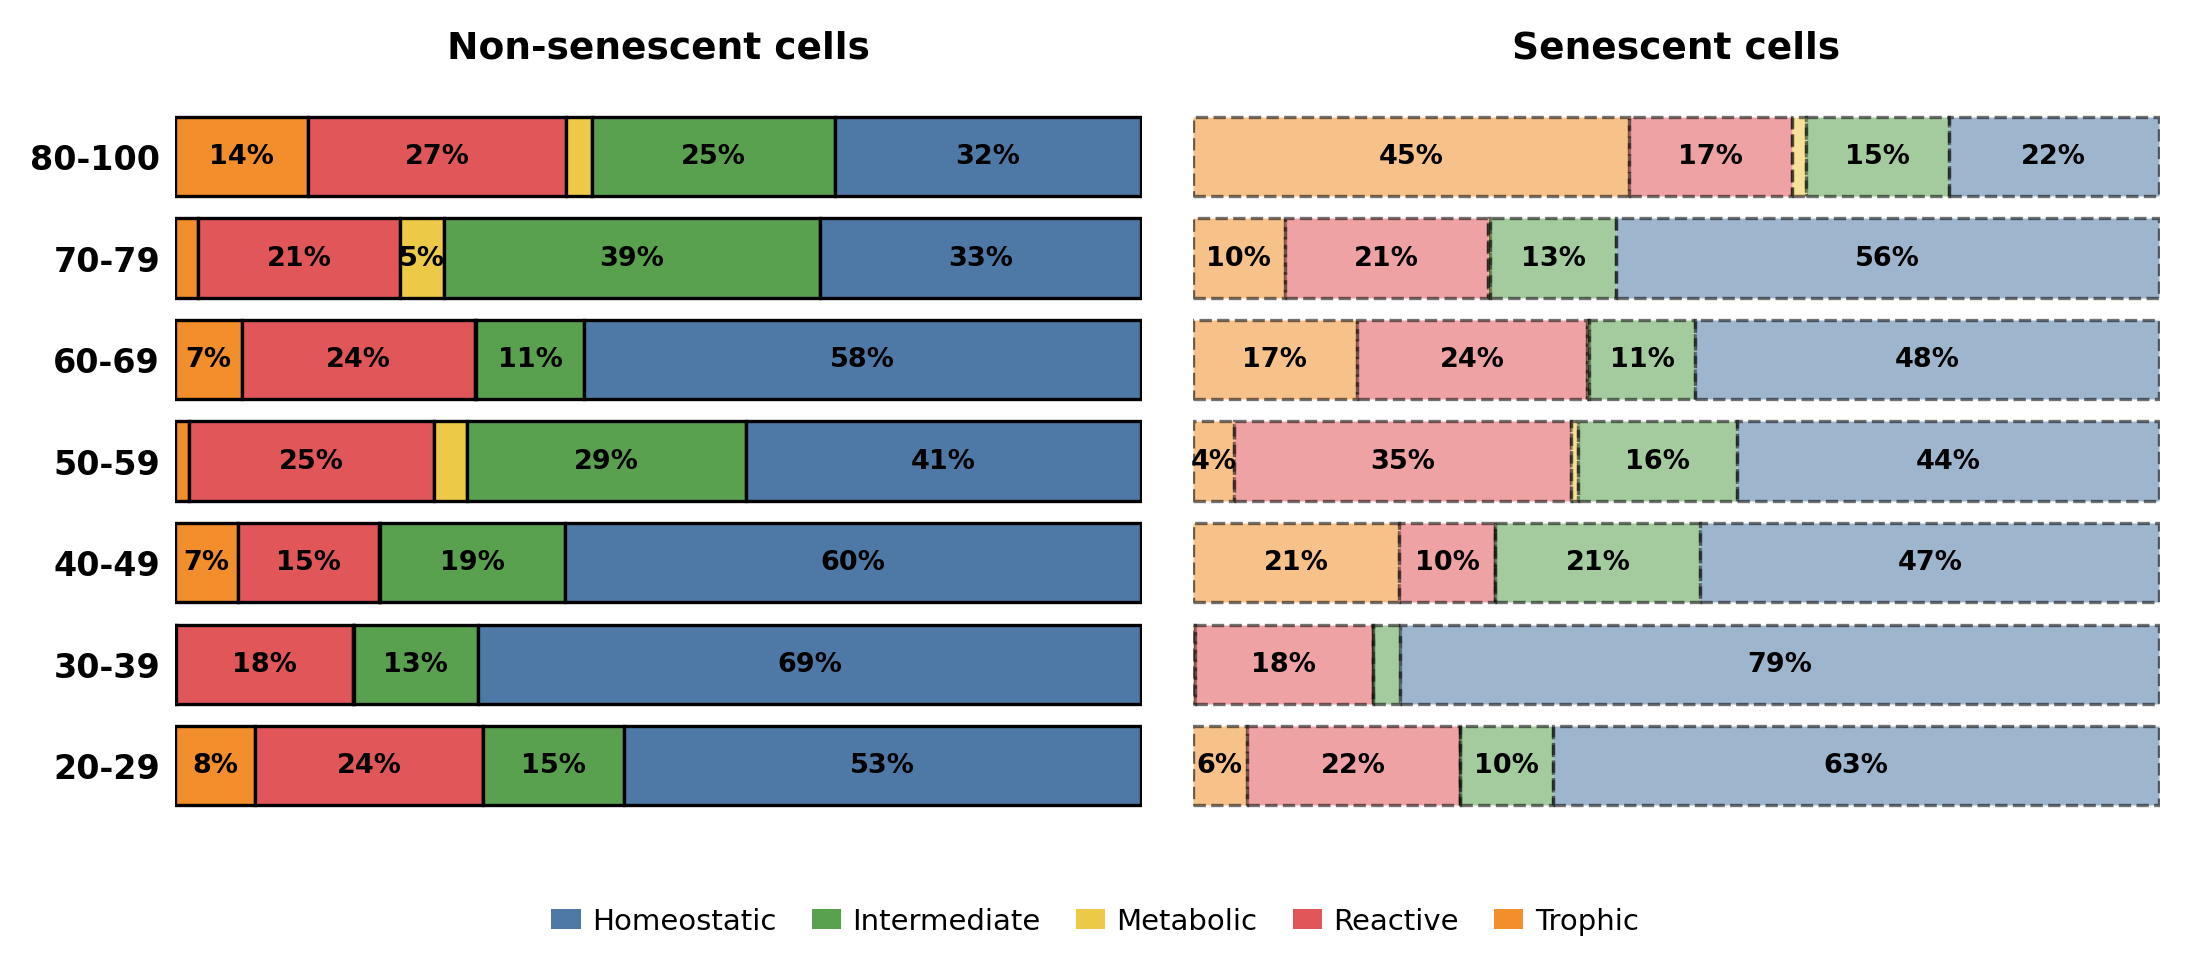

In [6]:
SRC = 'results/fig3D_source_data.csv'
GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
               'Age_60_69', 'Age_70_79', 'Age_80_100']
PANEL_ORDER = ['Non-SnC', 'SnC']
PANEL_TITLE = {'Non-SnC': 'Non-senescent cells', 'SnC': 'Senescent cells'}
PANEL_STYLE = {'Non-SnC': dict(alpha=1.00, ls='-',  lw=0.8),
               'SnC':     dict(alpha=0.55, ls='--', lw=0.8)}
LABEL_MIN = 4.0
# significance per state, appended to the first group's label. {panel: {state: sym}}
ANNOT = {}
BAR_H = 0.78

import numpy as np, pandas as pd, matplotlib.pyplot as plt

if 'color_for' not in globals():
    raise NameError("run the settings cell first")

d = pd.read_csv(SRC)
STATE_ORDER = sorted(d.State.unique())[::-1]      # rev(alphabetical), base first
cmap = dict(zip(STATE_ORDER, color_for('cell_type', STATE_ORDER)))
print("Fig3D colours:", cmap)
print("stack order, left to right:", STATE_ORDER)

fig, axes = plt.subplots(1, len(PANEL_ORDER), figsize=(7.4, 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, pn in zip(axes, PANEL_ORDER):
    sub = d[d.senescence_label == pn]
    m = sub.pivot(index='Study_Group', columns='State', values='pct') \
           .reindex(index=GROUP_ORDER, columns=STATE_ORDER).fillna(0)
    y = np.arange(len(GROUP_ORDER))
    left = np.zeros(len(GROUP_ORDER))
    st = PANEL_STYLE[pn]
    for s in STATE_ORDER:
        v = m[s].values
        ax.barh(y, v, left=left, height=BAR_H, color=cmap[s], alpha=st['alpha'],
                edgecolor='black', linewidth=st['lw'], linestyle=st['ls'], zorder=2)
        for i, (vi, li) in enumerate(zip(v, left)):
            if vi >= LABEL_MIN:
                lab = f"{vi:.0f}%"
                if i == 0:
                    lab += ANNOT.get(pn, {}).get(s, '')
                ax.text(li + vi / 2, y[i], lab, ha='center', va='center',
                        fontsize=6.5, fontweight='bold', color='black', zorder=5)
        left = left + v
    ax.set_title(PANEL_TITLE.get(pn, pn), fontsize=9, fontweight='bold')
    ax.set_xlim(0, 100.1); ax.set_xticks([])
    ax.set_yticks(y)
    ax.set_yticklabels([g.replace('Age_', '').replace('_', '-') for g in GROUP_ORDER],
                       fontsize=8, fontweight='bold')
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(length=0)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=cmap[s], edgecolor='none')
           for s in STATE_ORDER[::-1]]
fig.legend(handles, STATE_ORDER[::-1], loc='lower center', ncol=len(STATE_ORDER),
           frameon=False, fontsize=7, handlelength=1.0, handletextpad=0.4,
           columnspacing=1.2, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# Figure 3E

In [ ]:
SRC = 'results/fig3E_source_data.csv'
STATE_ORDER = ['Homeostatic', 'COP', 'Reactive']
GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
               'Age_60_69', 'Age_70_79', 'Age_80_100']
NCOL_SMALL  = 4
SEED        = 0
S_BIG, S_SMALL = 1.1, 1.0
ALPHA       = 0.6
RASTERIZE   = True
PAD         = 0.04

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

if 'color_for' not in globals():
    raise NameError("run the settings cell first")

d = pd.read_csv(SRC)
bad = sorted(set(d.state) - set(STATE_ORDER)) + sorted(set(d.group) - set(GROUP_ORDER))
if bad:
    raise ValueError(f"levels not in ORDER: {bad}")
cmap = dict(zip(STATE_ORDER, color_for('cell_type', STATE_ORDER)))
print("Fig3E colours:", cmap)
print(f"{len(d):,} cells")
print(d.groupby('group', observed=True).size().reindex(GROUP_ORDER).to_string())

xr = d.UMAP1.max() - d.UMAP1.min(); yr = d.UMAP2.max() - d.UMAP2.min()
XL = (d.UMAP1.min() - PAD*xr, d.UMAP1.max() + PAD*xr)
YL = (d.UMAP2.min() - PAD*yr, d.UMAP2.max() + PAD*yr)
rng = np.random.default_rng(SEED)

def draw(ax, sub, s):
    sub = sub.iloc[rng.permutation(len(sub))]
    ax.scatter(sub.UMAP1, sub.UMAP2, s=s, c=sub.state.map(cmap).values,
               alpha=ALPHA, linewidths=0, rasterized=RASTERIZE)
    ax.set_xlim(*XL); ax.set_ylim(*YL)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig = plt.figure(figsize=(3.0 + 1.75*NCOL_SMALL, 5.4))
gs  = GridSpec(2, 2 + NCOL_SMALL, figure=fig, wspace=0.06, hspace=0.14)

axb = fig.add_subplot(gs[0:2, 0:2])
draw(axb, d, S_BIG)
axb.legend(handles=[Line2D([], [], marker='o', color='w', markerfacecolor=cmap[s],
                           markersize=5, label=s) for s in STATE_ORDER],
           loc='upper left', frameon=False, fontsize=7,
           handletextpad=0.3, labelspacing=0.3)

for i, g in enumerate(GROUP_ORDER):
    ax = fig.add_subplot(gs[i // NCOL_SMALL, 2 + i % NCOL_SMALL])
    sub = d[d.group == g]
    draw(ax, sub, S_SMALL)
    ax.set_title(f"{g.replace('Age_', 'Age-').replace('_', '-')}\n(n={len(sub):,})",
                 fontsize=7, fontweight='bold')
for i in range(len(GROUP_ORDER), 2 * NCOL_SMALL):
    fig.add_subplot(gs[i // NCOL_SMALL, 2 + i % NCOL_SMALL]).set_visible(False)

plt.show()

# Figure 3F

In [ ]:
SRC = 'results/fig3E_source_data.csv'
STACK_ORDER = ['Homeostatic', 'COP', 'Reactive']     # bottom to top
GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
               'Age_60_69', 'Age_70_79', 'Age_80_100']
# significance from the per-decade trend test. {state: {group: symbol}}
ANNOT = {}
BAR_W = 0.72

import numpy as np, pandas as pd, matplotlib.pyplot as plt

if 'color_for' not in globals():
    raise NameError("run the settings cell first")

d = pd.read_csv(SRC)
cmap = dict(zip(STACK_ORDER, color_for('cell_type', STACK_ORDER)))
print("Fig3F colours:", cmap)

n = pd.crosstab(d.group, d.state).reindex(index=GROUP_ORDER,
                                          columns=STACK_ORDER).fillna(0)
pct = n.div(n.sum(axis=1), axis=0) * 100
print("cells per group:", n.sum(axis=1).astype(int).to_dict())
print("\nproportion (%)")
print(pct.round(2).to_string())

x, bottom = np.arange(len(GROUP_ORDER)), np.zeros(len(GROUP_ORDER))
fig, ax = plt.subplots(figsize=(4.4, 3.6))
for st in STACK_ORDER:
    v = pct[st].values
    ax.bar(x, v, bottom=bottom, width=BAR_W, color=cmap[st],
           edgecolor='white', linewidth=0.5, label=st, zorder=2)
    for g, sym in ANNOT.get(st, {}).items():
        if g in GROUP_ORDER:
            i = GROUP_ORDER.index(g)
            ax.text(x[i], bottom[i] + v[i] / 2, sym, ha='center', va='center',
                    fontsize=11, fontweight='bold', zorder=5)
    bottom = bottom + v

ax.set_xticks(x)
ax.set_xticklabels([g.replace('Age_', 'Age-').replace('_', '-') for g in GROUP_ORDER],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion (%)', fontsize=9, fontweight='bold')
ax.set_xlabel('Age Group (years)', fontsize=9, fontweight='bold')
ax.set_ylim(0, 100); ax.set_yticks([0, 25, 50, 75, 100])
ax.tick_params(labelsize=8)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

# Figure 3G

In [ ]:
SRC = 'results/fig3G_source_data.csv'
ORDER_BY_MEDIAN = True          # False keeps the file's order
STATE_ORDER = ["Reactive", "Homeostatic", "COP"]              # or ['Homeostatic', 'COP', 'Reactive']
JITTER_SEED = 42                # seed i uses JITTER_SEED + i, matching the R original
JITTER_W    = 0.10
BOX_HW      = 0.25
BOX_ALPHA   = 0.7
DOT_ALPHA   = 0.6
DOT_S       = 4

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

if 'color_for' not in globals():
    raise NameError("run the settings cell first")

d = pd.read_csv(SRC)

if STATE_ORDER is not None:
    order = list(STATE_ORDER)
elif ORDER_BY_MEDIAN:
    order = (d.groupby('state').pct_snc.median()
               .sort_values(ascending=False).index.tolist())
else:
    order = list(dict.fromkeys(d.state))
cmap = dict(zip(order, color_for('cell_type', order)))
print("Fig3G colours:", cmap)

print(f"{len(d)} rows, {len(order)} states, min cells {int(d.n_cells.min())}")
for s in order:
    v = d.loc[d.state == s, 'pct_snc']
    print(f"  {s:<14} median={v.median():5.1f}  mean={v.mean():5.1f}  n={len(v)}")

ymax = d.pct_snc.max() * 1.05
fig, ax = plt.subplots(figsize=(2.8, 2.5))

for i, s in enumerate(order, start=1):
    v = d.loc[d.state == s, 'pct_snc'].values
    c = cmap[s]
    q0, q1, q2, q3, q4 = np.quantile(v, [0, .25, .5, .75, 1])
    iqr = q3 - q1
    lo, hi = max(q0, q1 - 1.5 * iqr), min(q4, q3 + 1.5 * iqr)

    ax.add_patch(Rectangle((i - BOX_HW, q1), 2 * BOX_HW, q3 - q1,
                           facecolor=c, alpha=BOX_ALPHA, edgecolor='none', zorder=2))
    ax.plot([i - 0.22, i + 0.22], [q2, q2], color='#333333', lw=1.0, zorder=4)
    ax.plot([i, i], [lo, q1], color='#666666', lw=0.6, zorder=3)
    ax.plot([i, i], [q3, hi], color='#666666', lw=0.6, zorder=3)
    for y in (lo, hi):
        ax.plot([i - 0.1, i + 0.1], [y, y], color='#666666', lw=0.6, zorder=3)

    rng = np.random.default_rng(JITTER_SEED + i)
    ax.scatter(i + rng.uniform(-JITTER_W, JITTER_W, len(v)), v,
               s=DOT_S, color=c, alpha=DOT_ALPHA, linewidths=0, zorder=5)

ax.set_xlim(0.4, len(order) + 0.6)
ax.set_ylim(0, ymax)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=90, fontsize=6, color='#333333')
ax.set_ylabel('SnC (%)', fontsize=6.5)
ax.tick_params(axis='y', labelsize=5.5, colors='#333333', length=2)
ax.tick_params(axis='x', length=2, colors='#333333')
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_color('#333333'); ax.spines[sp].set_linewidth(0.4)
fig.tight_layout()
plt.show()

# Figure 3H

In [ ]:
SRC = 'results/fig3H_source_data.csv'
GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
               'Age_60_69', 'Age_70_79', 'Age_80_100']
PANEL_ORDER = ['Non-SnC', 'SnC']
PANEL_TITLE = {'Non-SnC': 'Non-senescent cells', 'SnC': 'Senescent cells'}
PANEL_STYLE = {'Non-SnC': dict(alpha=1.00, ls='-',  lw=0.8),
               'SnC':     dict(alpha=0.55, ls='--', lw=0.8)}
STATE_ORDER = None          # None = rev(alphabetical), matching the R factor order
LABEL_MIN = 4.0
ANNOT = {}                  # {panel: {state: symbol}} from fig3H_stats.csv
BAR_H = 0.78

import numpy as np, pandas as pd, matplotlib.pyplot as plt

if 'color_for' not in globals():
    raise NameError("run the settings cell first")

d = pd.read_csv(SRC)
order = list(STATE_ORDER) if STATE_ORDER else sorted(d.State.unique())[::-1]
cmap = dict(zip(order, color_for('cell_type', order)))
print("Fig3H colours:", cmap)
print("stack order, left to right:", order)
print("\ncells per group x panel")
print(d.pivot_table(index='Study_Group', columns='senescence_label',
                    values='n', aggfunc='sum')
       .reindex(GROUP_ORDER).astype(int).to_string())

fig, axes = plt.subplots(1, len(PANEL_ORDER), figsize=(7.4, 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, pn in zip(axes, PANEL_ORDER):
    sub = d[d.senescence_label == pn]
    m = sub.pivot(index='Study_Group', columns='State', values='pct') \
           .reindex(index=GROUP_ORDER, columns=order).fillna(0)
    y = np.arange(len(GROUP_ORDER))
    left = np.zeros(len(GROUP_ORDER))
    st = PANEL_STYLE[pn]
    for s in order:
        v = m[s].values
        ax.barh(y, v, left=left, height=BAR_H, color=cmap[s], alpha=st['alpha'],
                edgecolor='black', linewidth=st['lw'], linestyle=st['ls'], zorder=2)
        for i, (vi, li) in enumerate(zip(v, left)):
            if vi >= LABEL_MIN:
                lab = f"{vi:.0f}%"
                if i == 0:
                    lab += ANNOT.get(pn, {}).get(s, '')
                ax.text(li + vi / 2, y[i], lab, ha='center', va='center',
                        fontsize=6.5, fontweight='bold', color='black', zorder=5)
        left = left + v
    ax.set_title(PANEL_TITLE.get(pn, pn), fontsize=9, fontweight='bold')
    ax.set_xlim(0, 100.1); ax.set_xticks([])
    ax.set_yticks(y)
    ax.set_yticklabels([g.replace('Age_', '').replace('_', '-') for g in GROUP_ORDER],
                       fontsize=8, fontweight='bold')
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(length=0)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=cmap[s], edgecolor='none')
           for s in order[::-1]]
fig.legend(handles, order[::-1], loc='lower center', ncol=len(order),
           frameon=False, fontsize=7, handlelength=1.0, handletextpad=0.4,
           columnspacing=1.2, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()